In [1]:
import sys
sys.path.insert(0, '/Users/lyuan13/Downloads/pca_sphere_projection/')
import pca_sphere_projection.core as pc

import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import seaborn as sns
from scipy.spatial.transform import Rotation as R
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from scipy.stats import pearsonr
import matplotlib.cm as cm
import statsmodels.stats.multitest as smm

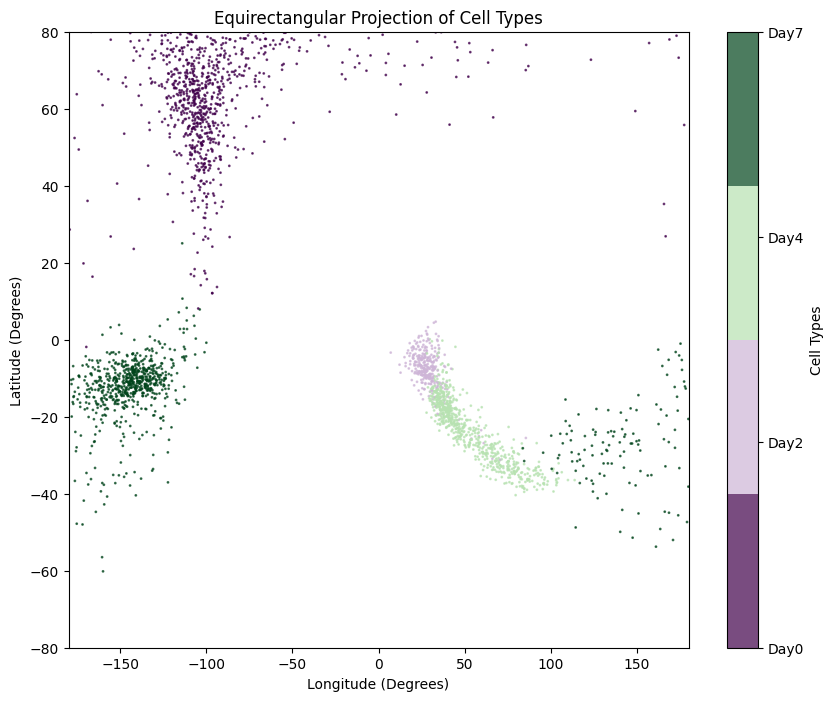

In [3]:
data = pd.read_csv('klein_pca.csv')
centroid = data[data['cluster'] == 'Day0'][['PC1', 'PC2', 'PC3']].mean().values

data = pc.align_to_north_pole(data, pcs_columns=['PC1', 'PC2', 'PC3'], cluster_column='cluster', root_node=centroid)
data = pc.apply_euler_rotation(data, pcs_columns=['PC1', 'PC2', 'PC3'], rotation_angles=[30,0,0], degrees=True)
pc.equirectangular_projection(data, 
                              pcs_columns=['rotated_PC1', 'rotated_PC2', 'rotated_PC3'], 
                              cluster_column='cluster', 
                              categories=None, 
                              selected_celltypes=None, 
                              colormap='PRGn', 
                              figsize=(10, 8), 
                              point_size=1, 
                              alpha=0.7, 
                              xlim=(-180, 180), 
                              ylim=(-80, 80))

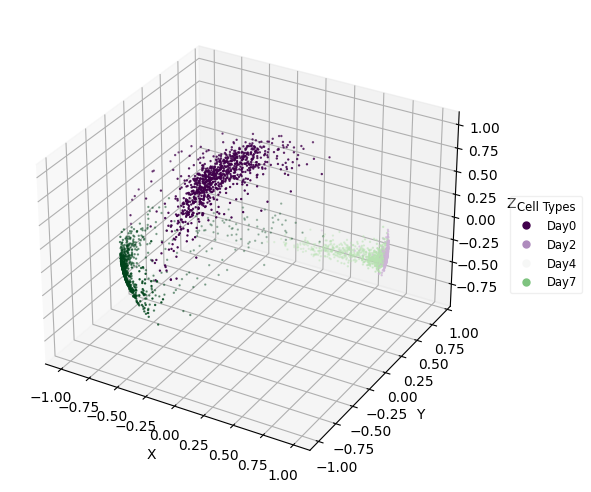

In [4]:
pc.visualize_globe( data, 
                    pcs_columns=['rotated_PC1', 'rotated_PC2', 'rotated_PC3'], 
                    cluster_column='cluster', 
                    colormap='PRGn', 
                    point_size=0.5, 
                    interactive=False, 
                    output_html=None, 
                    figsize=(6, 6), 
                    legend_columns=1)

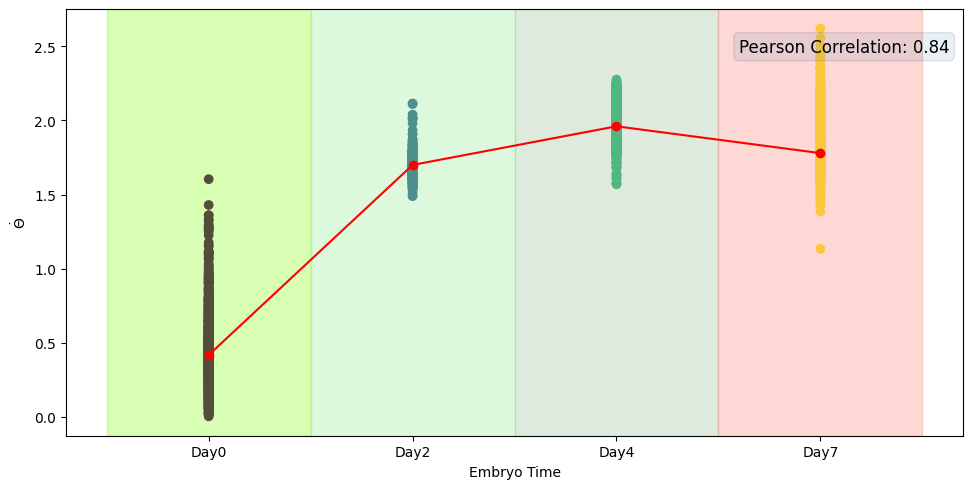

In [5]:
cell_types_of_interest = ['Day0', 'Day2', 'Day4', 'Day7']
filtered_data = data[data['cluster'].isin(cell_types_of_interest)].copy()

filtered_data['cluster'] = pd.Categorical(filtered_data['cluster'], categories=cell_types_of_interest, ordered=True)

filtered_data[['theta', 'phi']] = filtered_data.apply(
    lambda row: pc.calculate_spherical_angles(row['rotated_PC1'], row['rotated_PC2'], row['rotated_PC3']), axis=1, result_type='expand'
)


stages = {
    'Day0': (0, 2.5),          
    'Day2': (2.5, 5),   
    'Day4': (5, 7.5),        
    'Day7': (7.5, 10)     
}

category_scale = {
    'Day0': 1.25,  
    'Day2': 3.75,
    'Day4': 6.25,
    'Day7': 8.75  
}


filtered_data['pseudotime_mapped'] = filtered_data['cluster'].map(category_scale)
correlation, p_value = pearsonr(filtered_data['pseudotime_mapped'], filtered_data['theta'])

fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(filtered_data['pseudotime_mapped'], filtered_data['theta'],
                     c=filtered_data['cluster'].cat.codes, cmap='viridis')
ax.set_xticks(list(category_scale.values()))
ax.set_xticklabels(cell_types_of_interest)

medians = filtered_data.groupby('cluster')['theta'].median()
ax.plot([category_scale[cat] for cat in medians.index], medians.values, marker='o', linestyle='-', color='red', label='Median Theta')

colors = ['lawngreen', 'lightgreen', 'darkseagreen', 'salmon']
for stage, interval in stages.items():
    ax.axvspan(interval[0], interval[1], color=colors.pop(0), alpha=0.3, label=stage)

ax.set_xlabel('Embryo Time')
ax.set_ylabel(r"$\dot{\Theta}$")
plt.annotate(f'Pearson Correlation: {correlation:.2f}', xy=(0.75, 0.90), xycoords='axes fraction', fontsize=12, bbox=dict(boxstyle="round", alpha=0.1))
plt.tight_layout()
plt.show()